# Przykład zastosowania regresji liniowej

## Biblioteki

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
sns.set()

## wczytywanie danych

In [2]:
raw_data = pd.read_csv('cars.csv')

raw_data.sample(3)

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
962,Audi,22800.0,sedan,122,2.0,Petrol,yes,2011,A6
4295,BMW,17000.0,vagon,158,2.0,Diesel,yes,2010,320
2586,Volkswagen,11800.0,van,230,1.9,Diesel,yes,2009,T5 (Transporter)


## Wstępna obróbka danych

### Statystyki opisowe

In [3]:
# Funkcja .describe() domyślnie wylicza statystyki opisowe tylko dla zmiennych liczbowych
# aby wyliczał je także dla zmiennych kategorycznych ustawiamy parametr include='all'
raw_data.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,4345,4173.000000,4345,4345.000000,4195.000000,4345,4345,4345.000000,4345
unique,7,NaN,6,NaN,NaN,4,2,NaN,312
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,936,NaN,1649,NaN,NaN,2019,3947,NaN,199
mean,NaN,19418.746935,NaN,161.237284,2.790734,NaN,NaN,2006.550058,NaN
std,NaN,25584.242620,NaN,105.705797,5.066437,NaN,NaN,6.719097,NaN
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000,NaN
25%,NaN,6999.000000,NaN,86.000000,1.800000,NaN,NaN,2003.000000,NaN
50%,NaN,11500.000000,NaN,155.000000,2.200000,NaN,NaN,2008.000000,NaN
75%,NaN,21700.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000,NaN


Każda marka ('Brand') samochodu ma wiele modeli. Zobaczmy jak wiele 

In [4]:
raw_data['Model'].value_counts()

Model
E-Class    199
A6         172
Vito       171
Kangoo     146
Camry      134
          ... 
5            1
S5           1
21           1
Vista        1
Scion        1
Name: count, Length: 312, dtype: int64

In [5]:
# Pozbywamy się kolumny 'Model' z naszej analizy
data = raw_data.drop(['Model'],axis=1)


data.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,4345,4173.000000,4345,4345.000000,4195.000000,4345,4345,4345.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,936,NaN,1649,NaN,NaN,2019,3947,NaN
mean,NaN,19418.746935,NaN,161.237284,2.790734,NaN,NaN,2006.550058
std,NaN,25584.242620,NaN,105.705797,5.066437,NaN,NaN,6.719097
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000
25%,NaN,6999.000000,NaN,86.000000,1.800000,NaN,NaN,2003.000000
50%,NaN,11500.000000,NaN,155.000000,2.200000,NaN,NaN,2008.000000
75%,NaN,21700.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000


### Brakujące wartości

In [6]:
data.isnull().sum()

Brand             0
Price           172
Body              0
Mileage           0
EngineV         150
Engine Type       0
Registration      0
Year              0
dtype: int64

In [7]:
# Niewielki odsetek wierszy zawiera brakujące dane. Po prostu je usuniemy
data_no_null = data.dropna(axis=0)

In [8]:
data_no_null.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,4025,4025.000000,4025,4025.000000,4025.000000,4025,4025,4025.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,880,NaN,1534,NaN,NaN,1861,3654,NaN
mean,NaN,19552.308065,NaN,163.572174,2.764586,NaN,NaN,2006.379627
std,NaN,25815.734988,NaN,103.394703,4.935941,NaN,NaN,6.695595
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000
25%,NaN,6999.000000,NaN,90.000000,1.800000,NaN,NaN,2003.000000
50%,NaN,11500.000000,NaN,158.000000,2.200000,NaN,NaN,2007.000000
75%,NaN,21900.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000


### Przegląd rozkładów

C:\Users\HP\anaconda3\envs\wad\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


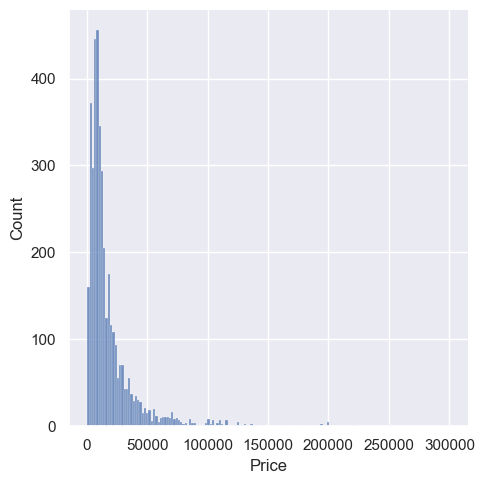

In [9]:
# Do narysowanie rozkładu stosujemy .displot() lub histplot() w seaborn
sns.displot(data_no_null['Price'])
plt.show()

### Wartości odstające

In [10]:
q = data_no_null['Price'].quantile(0.99)
q

129812.51999999981

In [11]:
data_1 = data_no_null[data_no_null['Price']<q]
data_1.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,3984,3984.000000,3984,3984.000000,3984.000000,3984,3984,3984.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,880,NaN,1528,NaN,NaN,1853,3613,NaN
mean,NaN,17837.117460,NaN,165.116466,2.743770,NaN,NaN,2006.292922
std,NaN,18976.268315,NaN,102.766126,4.956057,NaN,NaN,6.672745
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000
25%,NaN,6980.000000,NaN,93.000000,1.800000,NaN,NaN,2002.750000
50%,NaN,11400.000000,NaN,160.000000,2.200000,NaN,NaN,2007.000000
75%,NaN,21000.000000,NaN,230.000000,3.000000,NaN,NaN,2011.000000


C:\Users\HP\anaconda3\envs\wad\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


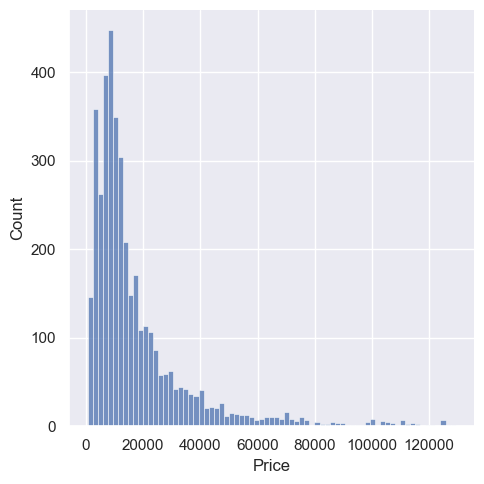

In [12]:
sns.displot(data_1['Price'])

C:\Users\HP\anaconda3\envs\wad\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


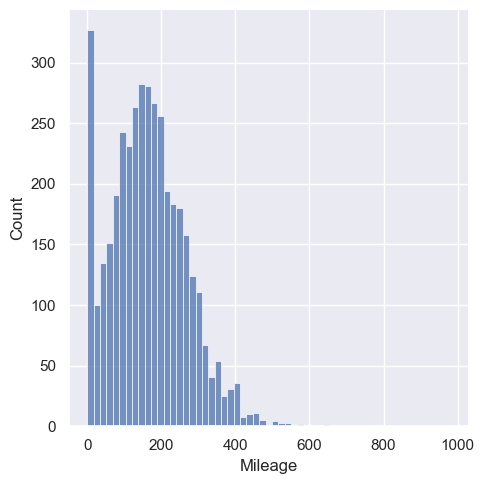

In [13]:
sns.displot(data_1['Mileage'])

In [14]:
q = data_1['Mileage'].quantile(0.99)
data_2 = data_1[data_1['Mileage']<q]

C:\Users\HP\anaconda3\envs\wad\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


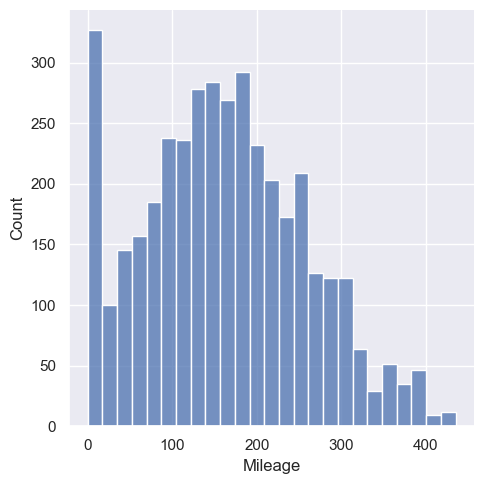

In [15]:
# This plot looks kind of normal, doesn't it?
sns.displot(data_2['Mileage'])

C:\Users\HP\anaconda3\envs\wad\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


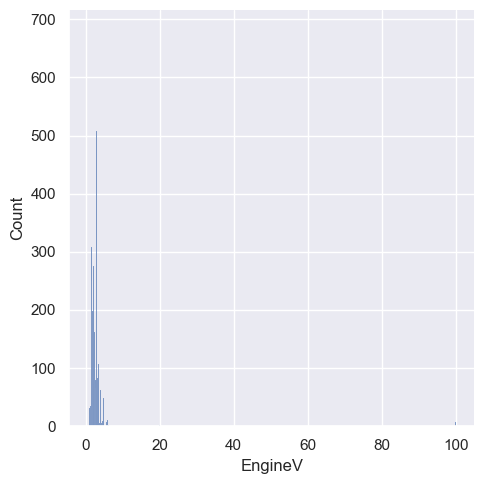

In [16]:
sns.displot(data_2['EngineV'])

In [17]:
# Pojemność silnika w samochodzie nie przekracza 6,5l
data_3 = data_2[data_2['EngineV']<6.5]

C:\Users\HP\anaconda3\envs\wad\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


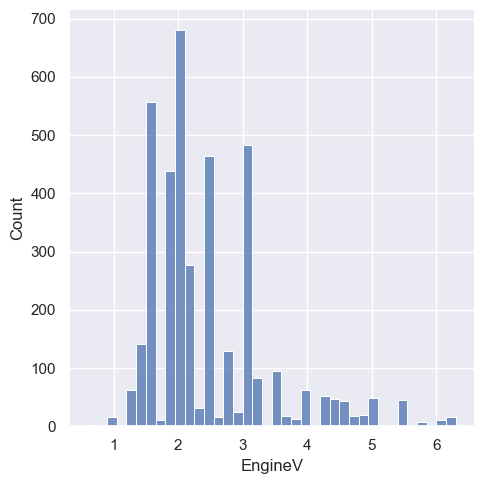

In [18]:
# Following this graph, we realize we can actually treat EngineV as a categorical variable
# Even so, in this course we won't, but that's yet something else you may try on your own
sns.displot(data_3['EngineV'])

C:\Users\HP\anaconda3\envs\wad\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


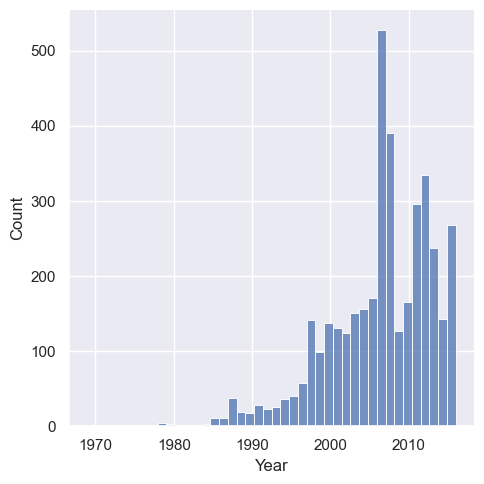

In [19]:
sns.displot(data_3['Year'])

In [20]:
# Usuwamy 1% najstarszych pojazdów
q = data_3['Year'].quantile(0.01)
data_4 = data_3[data_3['Year']>q]

C:\Users\HP\anaconda3\envs\wad\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


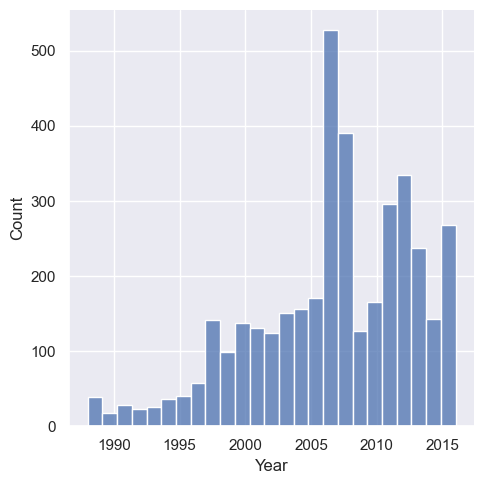

In [21]:
# Here's the new result
sns.displot(data_4['Year'])

In [22]:
data_4.tail(5)

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
4338,Volkswagen,11500.0,van,163,2.5,Diesel,yes,2008
4339,Toyota,17900.0,sedan,35,1.6,Petrol,yes,2014
4340,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014
4341,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999
4344,Volkswagen,13500.0,van,124,2.0,Diesel,yes,2013


In [23]:
# Widać, że po usunięciu pewnych obserwacji DataFrame zachowuje oryginalne indeksy.
# Skoro zakończyliśmy usuwanie wartości odstających, to należy zresetować indeksy
data_cleaned = data_4.reset_index(drop=True)

In [24]:
# Zobaczmy co zostało
data_cleaned.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,3867,3867.000000,3867,3867.000000,3867.000000,3867,3867,3867.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,848,NaN,1467,NaN,NaN,1807,3505,NaN
mean,NaN,18194.455679,NaN,160.542539,2.450440,NaN,NaN,2006.709853
std,NaN,19085.855165,NaN,95.633291,0.949366,NaN,NaN,6.103870
min,NaN,800.000000,NaN,0.000000,0.600000,NaN,NaN,1988.000000
25%,NaN,7200.000000,NaN,91.000000,1.800000,NaN,NaN,2003.000000
50%,NaN,11700.000000,NaN,157.000000,2.200000,NaN,NaN,2008.000000
75%,NaN,21700.000000,NaN,225.000000,3.000000,NaN,NaN,2012.000000


## Założenia regresji liniowej

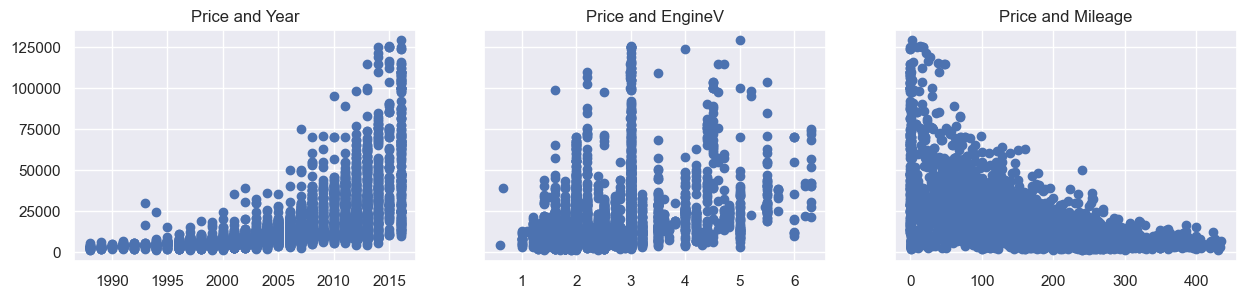

In [25]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize =(15,3)) #sharey ->  zmienna y wspólna dla wszystkich wykresów
ax1.scatter(data_cleaned['Year'],data_cleaned['Price'])
ax1.set_title('Price and Year')
ax2.scatter(data_cleaned['EngineV'],data_cleaned['Price'])
ax2.set_title('Price and EngineV')
ax3.scatter(data_cleaned['Mileage'],data_cleaned['Price'])
ax3.set_title('Price and Mileage')


plt.show()

C:\Users\HP\anaconda3\envs\wad\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


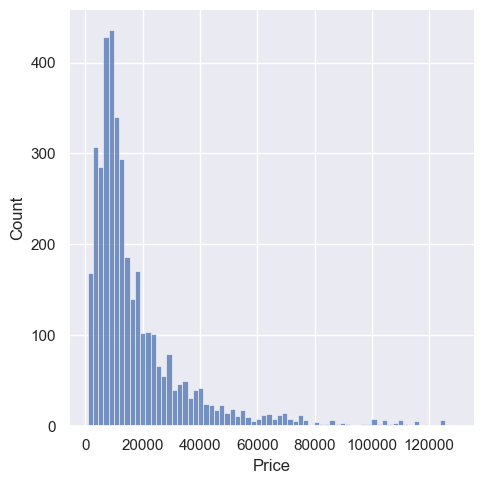

In [26]:
# Z histogramu dla 'Price' widać, że zmienna ta ma rozkład wykładniczy
sns.displot(data_cleaned['Price'])

### Logarytmiczna transformacja danych

In [27]:
log_price = np.log(data_cleaned['Price'])

data_cleaned['log_price'] = log_price
data_cleaned.head(5)

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,log_price
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,8.342840
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,8.974618
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,9.495519
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,10.043249
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,9.814656


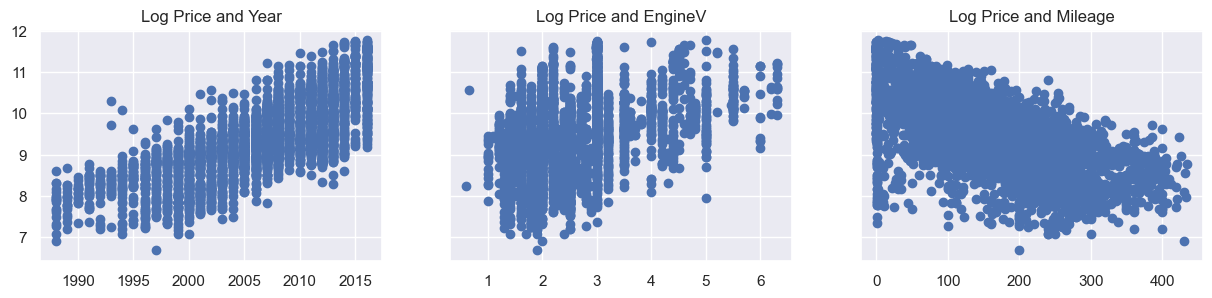

In [28]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize =(15,3))
ax1.scatter(data_cleaned['Year'],data_cleaned['log_price'])
ax1.set_title('Log Price and Year')
ax2.scatter(data_cleaned['EngineV'],data_cleaned['log_price'])
ax2.set_title('Log Price and EngineV')
ax3.scatter(data_cleaned['Mileage'],data_cleaned['log_price'])
ax3.set_title('Log Price and Mileage')


plt.show()

# Teraz widać zależność liniową

In [29]:
# Since we will be using the log price variable, we can drop the old 'Price' one
data_cleaned = data_cleaned.drop(['Price'],axis=1)

## Zmienne binarne (dummy variables)

In [30]:
data_with_dummies = pd.get_dummies(data_cleaned, drop_first=True)

In [31]:
data_with_dummies.head()

,Mileage,EngineV,Year,log_price,Brand_BMW,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Renault,Brand_Toyota,Brand_Volkswagen,Body_hatch,Body_other,Body_sedan,Body_vagon,Body_van,Engine Type_Gas,Engine Type_Other,Engine Type_Petrol,Registration_yes
0,277,2.0,1991,8.342840,True,False,False,False,False,False,False,False,True,False,False,False,False,True,True
1,427,2.9,1999,8.974618,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True
2,358,5.0,2003,9.495519,False,True,False,False,False,False,False,False,True,False,False,True,False,False,True
3,240,4.2,2007,10.043249,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
4,120,2.0,2011,9.814656,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True


### Zmianna kolejności zmiennych

In [32]:
data_with_dummies.columns.values

array(['Mileage', 'EngineV', 'Year', 'log_price', 'Brand_BMW',
       'Brand_Mercedes-Benz', 'Brand_Mitsubishi', 'Brand_Renault',
       'Brand_Toyota', 'Brand_Volkswagen', 'Body_hatch', 'Body_other',
       'Body_sedan', 'Body_vagon', 'Body_van', 'Engine Type_Gas',
       'Engine Type_Other', 'Engine Type_Petrol', 'Registration_yes'],
      dtype=object)

In [33]:
# Nowa kolejność: zmienna zależna (y), zmienne liczbowe, zmienne binarne
cols = ['log_price', 'Mileage', 'EngineV', 'Brand_BMW',
       'Brand_Mercedes-Benz', 'Brand_Mitsubishi', 'Brand_Renault',
       'Brand_Toyota', 'Brand_Volkswagen', 'Body_hatch', 'Body_other',
       'Body_sedan', 'Body_vagon', 'Body_van', 'Engine Type_Gas',
       'Engine Type_Other', 'Engine Type_Petrol', 'Registration_yes']

In [34]:
data_preprocessed = data_with_dummies[cols]
data_preprocessed.head()

,log_price,Mileage,EngineV,Brand_BMW,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Renault,Brand_Toyota,Brand_Volkswagen,Body_hatch,Body_other,Body_sedan,Body_vagon,Body_van,Engine Type_Gas,Engine Type_Other,Engine Type_Petrol,Registration_yes
0,8.342840,277,2.0,True,False,False,False,False,False,False,False,True,False,False,False,False,True,True
1,8.974618,427,2.9,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True
2,9.495519,358,5.0,False,True,False,False,False,False,False,False,True,False,False,True,False,False,True
3,10.043249,240,4.2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
4,9.814656,120,2.0,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True


## Model regresji liniowej

### deklarowanie zmiennych

In [35]:
y = data_preprocessed['log_price']

X = data_preprocessed.drop(['log_price'],axis=1)

### Standaryzacja zmiennych

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Wyliczanie odpowiednich parametrów do standaryzaji
scaler.fit(X)

StandardScaler()

In [37]:
# proces standaryzacji dla wyliczonych parametrów
X_scaled = scaler.transform(X)

### Zbiór treningowy i testowy

In [38]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=365)

### Budowanie modelu regresji na zbiorze treningowym

In [39]:
reg = LinearRegression()
reg.fit(x_train,y_train)

LinearRegression()

In [40]:
y_hat = reg.predict(x_train)

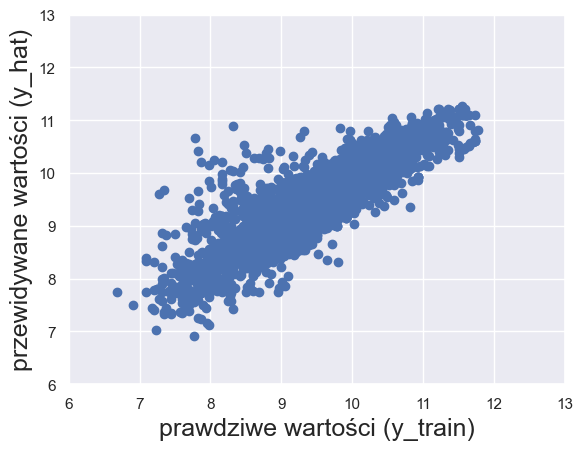

In [41]:
# Naprostszym sposobem porównania prawdziwych wartości y (y_train) i wartości przewidywanych (y_hat)
# jest umieszczenie ich na wykresie punktowym
# Im bliżej leżą wykresu prostej y=x tym lepiej
plt.scatter(y_train, y_hat)

plt.xlabel('prawdziwe wartości (y_train)',size=18)
plt.ylabel('przewidywane wartości (y_hat)',size=18)
# osie mogą mieć inne skale, więc trzeba te same skale wymusić
plt.xlim(6,13)
plt.ylim(6,13)
plt.show()

C:\Users\HP\anaconda3\envs\wad\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Reszty')

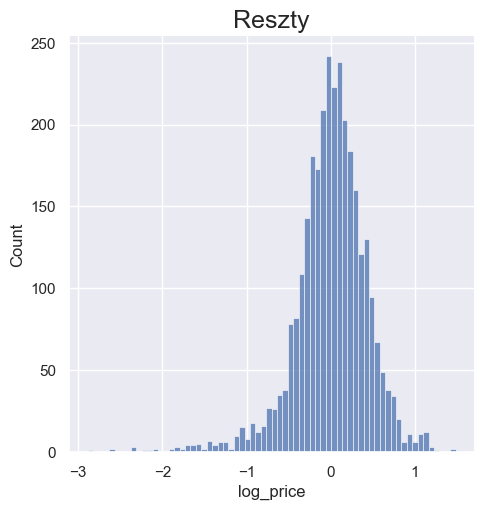

In [42]:
# Wykres reszt
sns.displot(y_train - y_hat)

plt.title("Reszty", size=18)

# oczekujemy rozkładu zbliżonego do normalnego

In [43]:
# Wartość R^2
reg.score(x_train,y_train)

0.744996578792662

### Współczynniki regresji

In [44]:
reg.intercept_

9.415239458021299

In [45]:
reg.coef_

array([-0.44871341,  0.20903483,  0.0142496 ,  0.01288174, -0.14055166,
       -0.17990912, -0.06054988, -0.08992433, -0.1454692 , -0.10144383,
       -0.20062984, -0.12988747, -0.16859669, -0.12149035, -0.03336798,
       -0.14690868,  0.32047333])

In [46]:
# Aby móc zinterpretować współczynniki tworzymy tabelę
reg_summary = pd.DataFrame(X.columns.values, columns=['Zmienne'])
reg_summary['Współczynniki'] = reg.coef_
reg_summary

,Zmienne,Współczynniki
0,Mileage,-0.448713
1,EngineV,0.209035
2,Brand_BMW,0.014250
3,Brand_Mercedes-Benz,0.012882
4,Brand_Mitsubishi,-0.140552
5,Brand_Renault,-0.179909
6,Brand_Toyota,-0.060550
7,Brand_Volkswagen,-0.089924
8,Body_hatch,-0.145469
9,Body_other,-0.101444


In [47]:
data_cleaned['Brand'].unique()

array(['BMW', 'Mercedes-Benz', 'Audi', 'Toyota', 'Renault', 'Volkswagen',
       'Mitsubishi'], dtype=object)

## Testowanie modelu

In [48]:
y_hat_test = reg.predict(x_test)

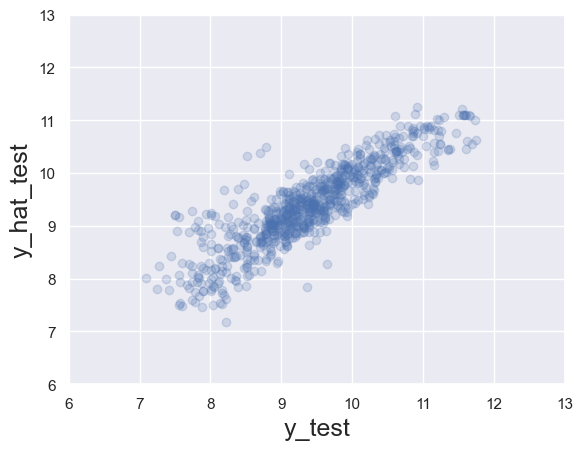

In [49]:
plt.scatter(y_test, y_hat_test, alpha=0.2)
plt.xlabel('y_test',size=18)
plt.ylabel('y_hat_test',size=18)
plt.xlim(6,13)
plt.ylim(6,13)
plt.show()

In [50]:
# predykcje - ponieważ estymowany jest logarytm cen, więc przykładamy funkcję wykładniczą, by poznać predykcje cen
np.exp(y_hat_test)

array([10685.50169649,  3499.25524233,  7553.28521809,  7463.96301686,
       11353.49007546, 21289.79939374, 20159.1891444 , 20349.61770212,
       11581.53786425, 33614.61734899,  7241.06824308,  5175.76954056,
        5484.01536239, 13292.71124349,  8248.66668587, 10621.83676682,
       23721.58163706, 11770.63600973, 37600.14672217, 16178.14330713,
       11876.8209881 , 31557.80499896,  6102.35811847, 13111.91414439,
       23650.15072464, 45272.2484113 ,  2178.94167188,  2555.02254239,
       35991.51053897, 26062.22941888, 15559.43286103, 12858.07948212,
       12459.85365928, 22941.79993935, 19854.79338212, 11337.51464634,
       10499.60420948, 26478.14599973,  9919.18592667, 16724.44786307,
       18672.67518267, 19845.35674105, 23286.2731319 , 21611.83358477,
        7241.06824308,  8512.02684393,  3542.72069208, 26425.13630985,
       77403.05522421,  4973.17459943,  2479.4308038 ,  2543.56917278,
       10716.84453646, 20453.88611802, 18575.42912968, 12674.57184672,
      

In [51]:
# wartości prawdziwe
np.exp(y_test)

1192     2300.0
3360     2800.0
2350     2500.0
3257     6400.0
892      9150.0
         ...   
1935    29500.0
3757     9600.0
3134    18300.0
1369    68500.0
2595    10800.0
Name: log_price, Length: 774, dtype: float64

Widać, że *y_hat_test* jest typu **numpy.array**, a *y_test* typu **pandas.Series**. Dodatkowo *y_test* ma indeksy wymieszane - skutek losowego podziału na zbiór uczący i testowy. Aby móc porównać te dwie zmienne potrzena zresetować indeksy dla *y_test*

In [52]:
df_pf = pd.DataFrame(np.exp(y_hat_test), columns=['Predykcja'])
df_pf.head()

,Predykcja
0,10685.501696
1,3499.255242
2,7553.285218
3,7463.963017
4,11353.490075


In [53]:
# zresetujmy indeksy
y_test = y_test.reset_index(drop=True)

y_test.head()

0    7.740664
1    7.937375
2    7.824046
3    8.764053
4    9.121509
Name: log_price, dtype: float64

In [54]:
df_pf['Wartość prawdziwa'] = np.exp(y_test)
df_pf

,Predykcja,Wartość prawdziwa
0,10685.501696,2300.0
1,3499.255242,2800.0
2,7553.285218,2500.0
3,7463.963017,6400.0
4,11353.490075,9150.0
...,...,...
769,29651.726363,29500.0
770,10732.071179,9600.0
771,13922.446953,18300.0
772,27487.751303,68500.0


In [55]:
df_pf['Reszty'] = df_pf['Wartość prawdziwa'] - df_pf['Predykcja']
df_pf['Różnica w %'] = np.absolute(df_pf['Reszty']/df_pf['Wartość prawdziwa']*100)
df_pf

,Predykcja,Wartość prawdziwa,Reszty,Różnica w %
0,10685.501696,2300.0,-8385.501696,364.587030
1,3499.255242,2800.0,-699.255242,24.973402
2,7553.285218,2500.0,-5053.285218,202.131409
3,7463.963017,6400.0,-1063.963017,16.624422
4,11353.490075,9150.0,-2203.490075,24.081859
...,...,...,...,...
769,29651.726363,29500.0,-151.726363,0.514327
770,10732.071179,9600.0,-1132.071179,11.792408
771,13922.446953,18300.0,4377.553047,23.921055
772,27487.751303,68500.0,41012.248697,59.871896


In [56]:
df_pf.describe()

,Predykcja,Wartość prawdziwa,Reszty,Różnica w %
count,774.000000,774.000000,774.000000,774.000000
mean,15946.760167,18165.817106,2219.056939,36.256693
std,13133.197604,19967.858908,10871.218143,55.066507
min,1320.562768,1200.000000,-29456.498331,0.062794
25%,7413.644234,6900.000000,-2044.191251,12.108022
50%,11568.168859,11600.000000,142.518577,23.467728
75%,20162.408805,20500.000000,3147.343497,39.563570
max,77403.055224,126000.000000,85106.162329,512.688080


In [57]:
pd.options.display.max_rows = 999
pd.set_option('display.float_format', lambda x: '%.2f' % x)
df_pf.sort_values(by=['Różnica w %'])

,Predykcja,Wartość prawdziwa,Reszty,Różnica w %
698,30480.85,30500.00,19.15,0.06
742,16960.31,16999.00,38.69,0.23
60,12469.21,12500.00,30.79,0.25
110,25614.14,25500.00,-114.14,0.45
367,42703.68,42500.00,-203.68,0.48
369,3084.69,3100.00,15.31,0.49
769,29651.73,29500.00,-151.73,0.51
272,9749.53,9800.00,50.47,0.52
714,23118.07,22999.00,-119.07,0.52
630,8734.58,8800.00,65.42,0.74
